## 1. Conceptual Explanation of Gradient Descent

### Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the cost function of a machine learning model. It works by iteratively adjusting the model parameters (such as slope and intercept in linear regression) in the direction that reduces the prediction error.

The algorithm calculates the gradient (slope) of the cost function with respect to the model parameters and updates them using a learning rate.

Update rule:

θ = θ − α * (∂J / ∂θ)

Where:

θ → model parameters  
α → learning rate  
J → cost function  
∂J/∂θ → gradient of the cost function  

The goal of gradient descent is to find the parameter values that minimize the cost function and produce the best model fit.

## 2. Implement Batch Gradient Descent From Scratch

# 2.1 Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2.2 READ & LOAD CSV FILE

In [2]:
dataset = pd.read_csv("Final_cleaned_realestate_houseprice.csv")

In [3]:
dataset.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,0.529749,0.904293,1.045104,0.962274,-0.030941,-0.764210,1.266330,1,0,-1.187943,40275084.00
1,-0.170338,-0.437056,0.161028,0.331502,-0.846958,-0.284951,0.375105,1,0,0.828587,26812029.00
2,0.695871,0.233618,0.161028,0.088897,-1.173365,0.366349,0.778754,0,0,0.208116,29315677.00
3,1.660397,0.904293,0.161028,1.010795,-0.928560,-1.255758,0.196594,1,1,-0.567472,46250249.55
4,-0.275436,-0.437056,0.161028,-0.881522,-0.683755,0.722721,-0.436855,0,0,1.138822,17724566.00


## 2.3 Prepare Data

In [4]:
# feature and target
X = dataset["area_sqft"].values
y = dataset["house_price_inr"].values

# normalize X for stability
X = (X - X.mean()) / X.std()

n = len(X)

## 2.4 Initialize Parameters

In [5]:
# initial parameters
w = 0
b = 0

learning_rate = 0.01
iterations = 1000

cost_history = []

## 2.5 Batch Gradient Descent Algorithm

In [6]:
for i in range(iterations):

    y_pred = w * X + b

    # gradients
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    # update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # cost function (MSE)
    cost = np.mean((y - y_pred) ** 2)

    cost_history.append(cost)

print("Final slope (w):", w)
print("Final intercept (b):", b)

Final slope (w): 8535497.268060984
Final intercept (b): 23360964.55663664


## 2.6 Predicted Values

In [7]:

result = pd.DataFrame({
    "Actual_price": y,
    "Predicted_price": y_pred
})

print(result.astype(int))

      Actual_price  Predicted_price
0         40275084         27882633
1         26812029         21907046
2         29315677         29300569
3         46250249         37533279
4         17724566         21009984
...            ...              ...
4195      18319188         18550299
4196      40340976         33525439
4197       6189628          8480060
4198       7916191          8103873
4199      34319843         28577132

[4200 rows x 2 columns]


## Graph 1 — Regression Line from Gradient Descent

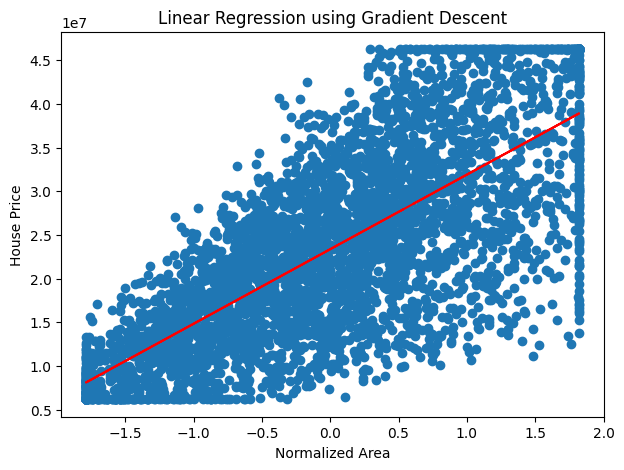

In [8]:
plt.figure(figsize=(7,5))

plt.scatter(X, y)

y_pred = w * X + b

plt.plot(X, y_pred, color="red")

plt.title("Linear Regression using Gradient Descent")
plt.xlabel("Normalized Area")
plt.ylabel("House Price")

plt.show()

The first graph shows the regression line obtained using gradient descent. The model learns the relationship between the independent variable and the target variable by iteratively updating the slope and intercept parameters.


## Graph 2 — Cost Function Convergence

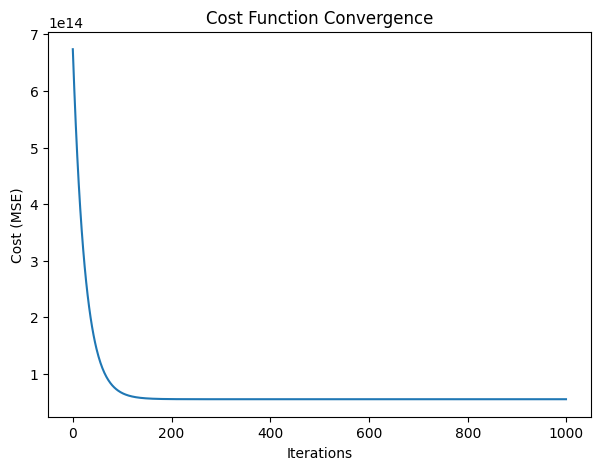

In [9]:
plt.figure(figsize=(7,5))

plt.plot(range(iterations), cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")

plt.title("Cost Function Convergence")

plt.show()

The second graph illustrates the convergence of the cost function during training. As the number of iterations increases, the cost decreases, indicating that the model is gradually minimizing the prediction error.


## Graph 3 — Parameter Convergence 

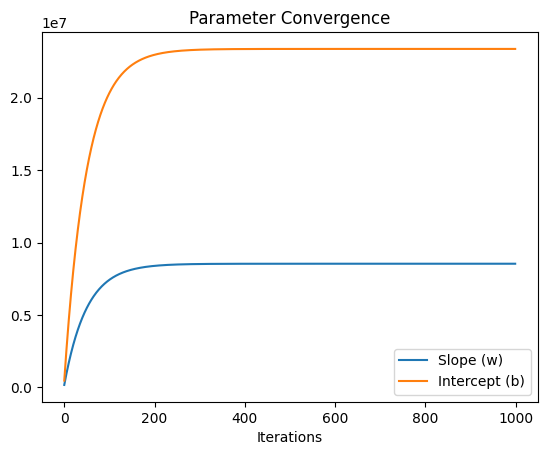

In [10]:
w_history = []
b_history = []

w = 0
b = 0

for i in range(iterations):

    y_pred = w * X + b

    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    w_history.append(w)
    b_history.append(b)

plt.plot(w_history, label="Slope (w)")
plt.plot(b_history, label="Intercept (b)")

plt.title("Parameter Convergence")

plt.xlabel("Iterations")
plt.legend()

plt.show()

The decreasing trend of the cost function demonstrates that gradient descent is successfully optimizing the model parameters.

## 2.7 Calculate Evaluation Metrics

## [A] Mean squared error

In [11]:
mse = mean_squared_error(y,y_pred)
print(f"Mean squared error : {mse}")

Mean squared error : 55187203159554.53


Mean Squared Error (MSE) calculates the average of squared errors, giving more importance to larger errors.

## [B] Mean absolute error

In [12]:
mae = mean_absolute_error(y,y_pred)
print(f"Mean absolute error : {mae}")

Mean absolute error : 5886183.680801631


Mean Absolute Error (MAE) measures the average absolute difference between the actual and predicted values.

## [C] Root mean sqaured error

In [13]:
rmse = np.sqrt(mse)
print(f"root mean sqaured error : {rmse}")

root mean sqaured error : 7428809.000072255


 Root Mean Squared Error (RMSE) is the square root of MSE and provides error values in the same units as the target variable.

## [D] R2 Score

In [14]:
r2 = r2_score(y,y_pred)
print(f"R2 score : {r2}")

R2 score : 0.5689911206823095


The R² Score indicates the proportion of variance in the target variable that is explained by the model. 

In [15]:
accurate_percentage_ = r2 * 100
print(f"Accurate Percentage : {accurate_percentage_}%")

Accurate Percentage : 56.89911206823095%


## [E] Adjusted r2 score

In [16]:
# Number of samples and predictors
n = len(y)
p = 1   # simple regression has 1 predictor

Adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted r2 score : {Adjusted_r2}")

Adjusted r2 score : 0.5688884506300662


Adjusted R² Score further adjusts the R² value based on the number of predictors used in the model.